### Validation Plotting

Training logs were lost due to a bug in the FileLogger. Hotfixing for weekly meeting: analyze passrates over validation logs.

In [ ]:
import os
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
root = "/ptmp/rfechner/out/exp05_train_qwen2.5-7b/"
dirs = os.listdir(root)

logpaths = {
    d : os.path.join(root, d, 'logs.jsonl') for d in dirs
}

In [3]:
logpaths

{'qwen2.5_7b__gtpo': '/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__gtpo/logs.jsonl',
 'qwen2.5_7b__grpo-s': '/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__grpo-s/logs.jsonl',
 'qwen2.5_7b__grpo': '/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__grpo/logs.jsonl',
 'qwen2.5_7b__clip-cov': '/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__clip-cov/logs.jsonl',
 'qwen2.5_7b__kl-cov': '/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__kl-cov/logs.jsonl',
 'qwen2.5_7b__dapo': '/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__dapo/logs.jsonl'}

In [4]:
from pathlib import Path
logmetrics = {}
for method, l in logpaths.items():
    try:
        with open(l, 'r') as file:
            tmp = pd.read_json(file, lines=True)['data'].to_list()
            df = pd.DataFrame(tmp)
            logmetrics[method] = df
    except:
        print(f"Failed method: {method}")

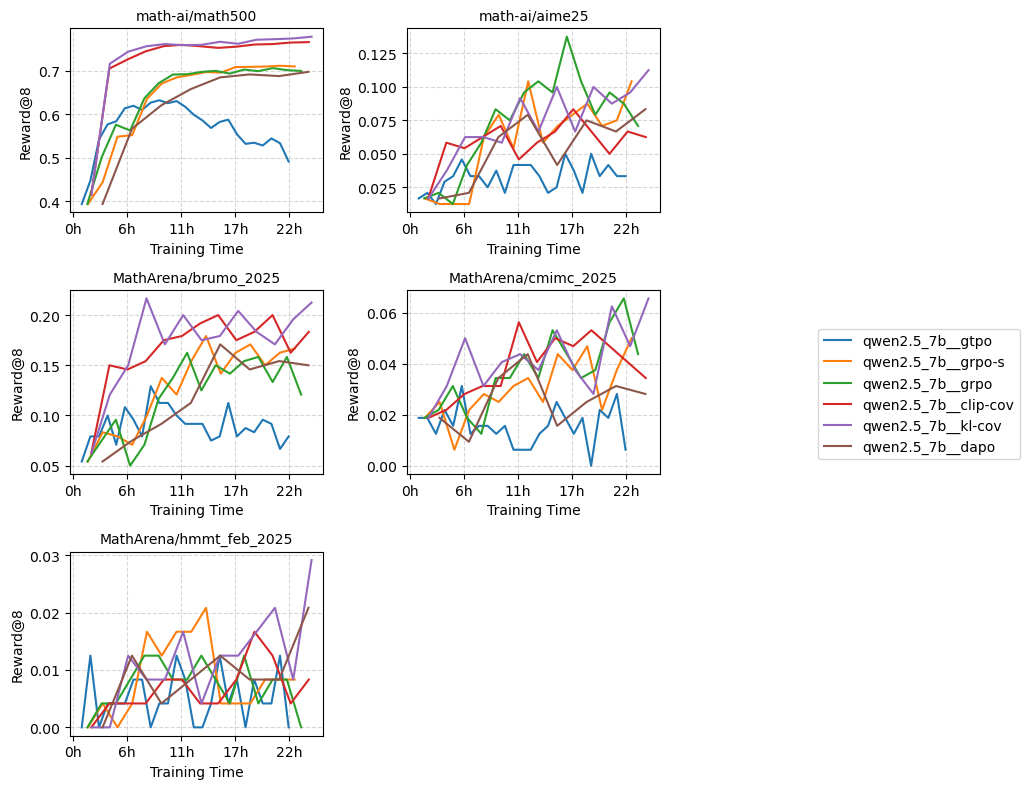

Failed method: qwen2.5_7b__clip-cov on key: actor/kl_loss — 'actor/kl_loss'
Failed method: qwen2.5_7b__kl-cov on key: actor/kl_loss — 'actor/kl_loss'
Failed method: qwen2.5_7b__dapo on key: actor/kl_loss — 'actor/kl_loss'


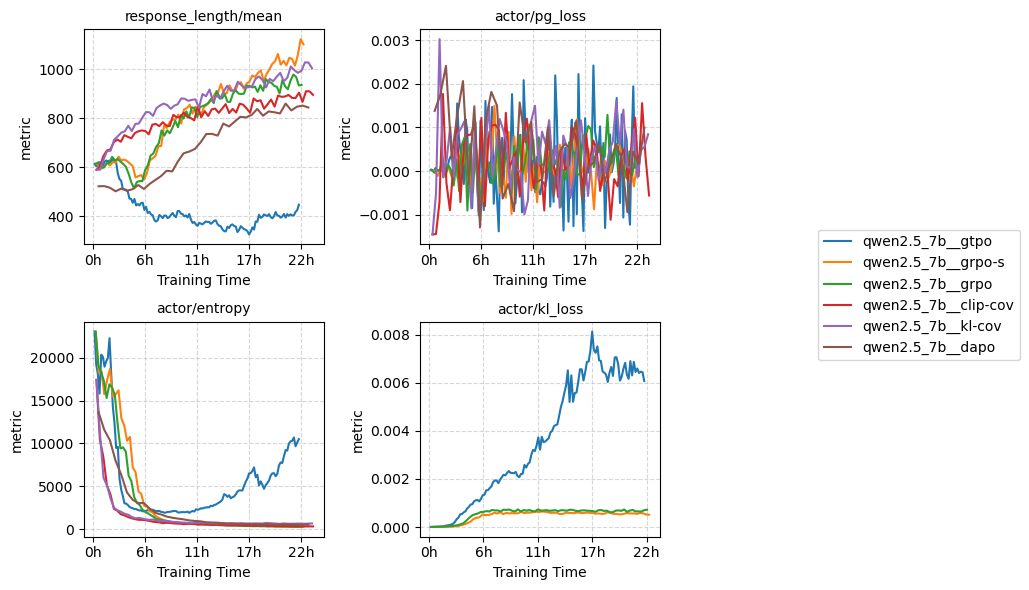

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

validation_keys = [
    "val-aux/math-ai/math500/reward/mean@8",
    "val-aux/math-ai/aime25/reward/mean@8",
    "val-aux/MathArena/brumo_2025/reward/mean@8",
    "val-aux/MathArena/cmimc_2025/reward/mean@8",
    "val-aux/MathArena/hmmt_feb_2025/reward/mean@8",
]

aux_keys = ['response_length/mean', 'actor/pg_loss', 'actor/entropy', 'actor/kl_loss']
timing_per_step_key = 'timing_s/step'
TEST_FREQ = 5.0


def _hours_formatter(x, pos):
    """Formatter: converts seconds to hours for x-axis."""
    return f"{x / 3600:.0f}h"


def plot_validation_metrics():
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(8, 8))
    axes = axes.flatten()

    # Remove the unused 6th subplot
    if len(validation_keys) < len(axes):
        fig.delaxes(axes[-1])
        axes = axes[:-1]

    for ax, key in zip(axes, validation_keys):
        for method, logs in logmetrics.items():
            try:
                timing_s = logs[timing_per_step_key].mean()
                ys = logs[key].to_numpy()
                ys = ys[~np.isnan(ys)]
                xs = [TEST_FREQ * (i + 1) * timing_s for i in range(len(ys))]
                ax.plot(xs, ys, label=method)
            except Exception as e:
                print(f"Failed method: {method} on key: {key} — {e}")

        # Clean up title
        clean_title = key.replace('val-aux/', '').replace('/reward/mean@8', '')
        ax.set_title(clean_title, fontsize=10)

        # Format x-axis in hours
        ax.xaxis.set_major_formatter(FuncFormatter(_hours_formatter))
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_xlabel('Training Time')
        ax.set_ylabel('Reward@8')

    # Place legend outside
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5))

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()


def plot_aux_metrics():
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 6))
    axes = axes.flatten()

    for ax, key in zip(axes, aux_keys):
        for method, logs in logmetrics.items():
            try:
                timing_s = logs[timing_per_step_key].mean()
                ys = np.array(logs[key])
                xs = np.arange(len(ys)) * timing_s
                ax.plot(xs, ys, label=method)
            except Exception as e:
                print(f"Failed method: {method} on key: {key} — {e}")

        ax.set_title(key, fontsize=10)
        ax.xaxis.set_major_formatter(FuncFormatter(_hours_formatter))
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_ylabel('metric')
        ax.set_xlabel('Training Time')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5))

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()


# Example usage:
plot_validation_metrics()
plot_aux_metrics()

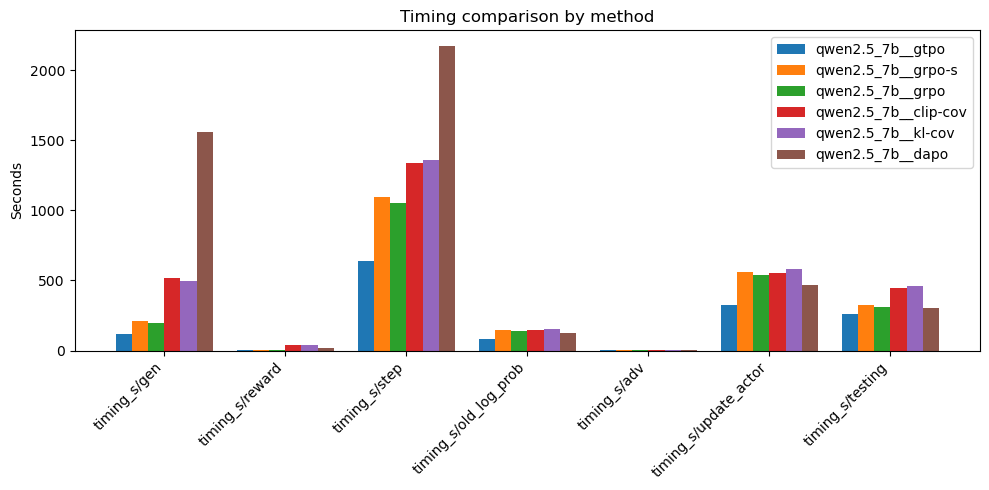

In [16]:
timing_keys = [
'timing_s/gen',
'timing_s/reward',
'timing_s/step',
'timing_s/old_log_prob',
'timing_s/adv',
'timing_s/update_actor',
'timing_s/testing']

methods = [m for m in logmetrics.keys()]

x = np.arange(len(timing_keys))  # positions for timing categories
bar_width = 0.8 / len(methods)   # width of each method's bar within a group

plt.figure(figsize=(10, 5))

for i, method in enumerate(methods):
    try:
        values = [logmetrics[method].get(k, 0) for k in timing_keys]
        values_mean = [np.mean(vs) for vs in values]
        plt.bar(x + i * bar_width, values_mean, width=bar_width, label=method)
    except Exception as e:
        print(f'failed method: {method}', e)

plt.xticks(x + bar_width * (len(methods) - 1) / 2, timing_keys, rotation=45, ha='right')
plt.ylabel('Seconds')
plt.title('Timing comparison by method')
plt.legend()
plt.tight_layout()
plt.show()